# 🛒 E-Commerce Intelligence Platform
## Phase 5 — Churn & Root Cause Analysis
**Goal:** Identify churned customers & find the root causes  
**Method:** Churn Definition → Pattern Analysis → Root Cause → Recommendations  
**Analyst:** Shivansh Pandey

In [1]:
# ============================================================
# CELL 1 — IMPORTS & UPLOAD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

from google.colab import files
uploaded = files.upload()

print("✅ Libraries imported & files uploaded")

Saving master_dataset.csv to master_dataset.csv
Saving rfm_segments.csv to rfm_segments.csv
✅ Libraries imported & files uploaded


In [2]:
# ============================================================
# CELL 2 — LOAD DATA
# ============================================================

master = pd.read_csv('master_dataset.csv')
rfm    = pd.read_csv('rfm_segments.csv')

master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'])

print(f"✅ Master dataset  : {master.shape}")
print(f"✅ RFM segments    : {rfm.shape}")
print(f"\n👥 Total unique customers : {master['customer_unique_id'].nunique():,}")

✅ Master dataset  : (110189, 29)
✅ RFM segments    : (93350, 10)

👥 Total unique customers : 93,350


In [3]:
# ============================================================
# CELL 3 — DEFINE CHURN
# A customer is churned if they haven't purchased
# in the last 180 days of the dataset
# This is a standard industry definition
# ============================================================

reference_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Get last purchase date per customer
last_purchase = master.groupby('customer_unique_id').agg(
    last_order_date = ('order_purchase_timestamp', 'max'),
    total_orders    = ('order_id',                 'nunique'),
    total_spend     = ('total_payment',             'sum'),
    avg_review      = ('review_score',              'mean'),
    late_orders     = ('is_late',                   'sum'),
    total_items     = ('order_item_id',             'count')
).reset_index()

# Calculate recency
last_purchase['recency_days'] = (
    reference_date - last_purchase['last_order_date']
).dt.days

# Define churn: no purchase in last 180 days
last_purchase['is_churned'] = (
    last_purchase['recency_days'] > 180
).astype(int)

churned     = last_purchase[last_purchase['is_churned'] == 1]
not_churned = last_purchase[last_purchase['is_churned'] == 0]

print(f"📊 Churn Analysis (180-day threshold):")
print(f"   Total Customers  : {len(last_purchase):,}")
print(f"   Churned          : {len(churned):,} ({len(churned)/len(last_purchase)*100:.1f}%)")
print(f"   Active           : {len(not_churned):,} ({len(not_churned)/len(last_purchase)*100:.1f}%)")

📊 Churn Analysis (180-day threshold):
   Total Customers  : 93,350
   Churned          : 55,250 (59.2%)
   Active           : 38,100 (40.8%)


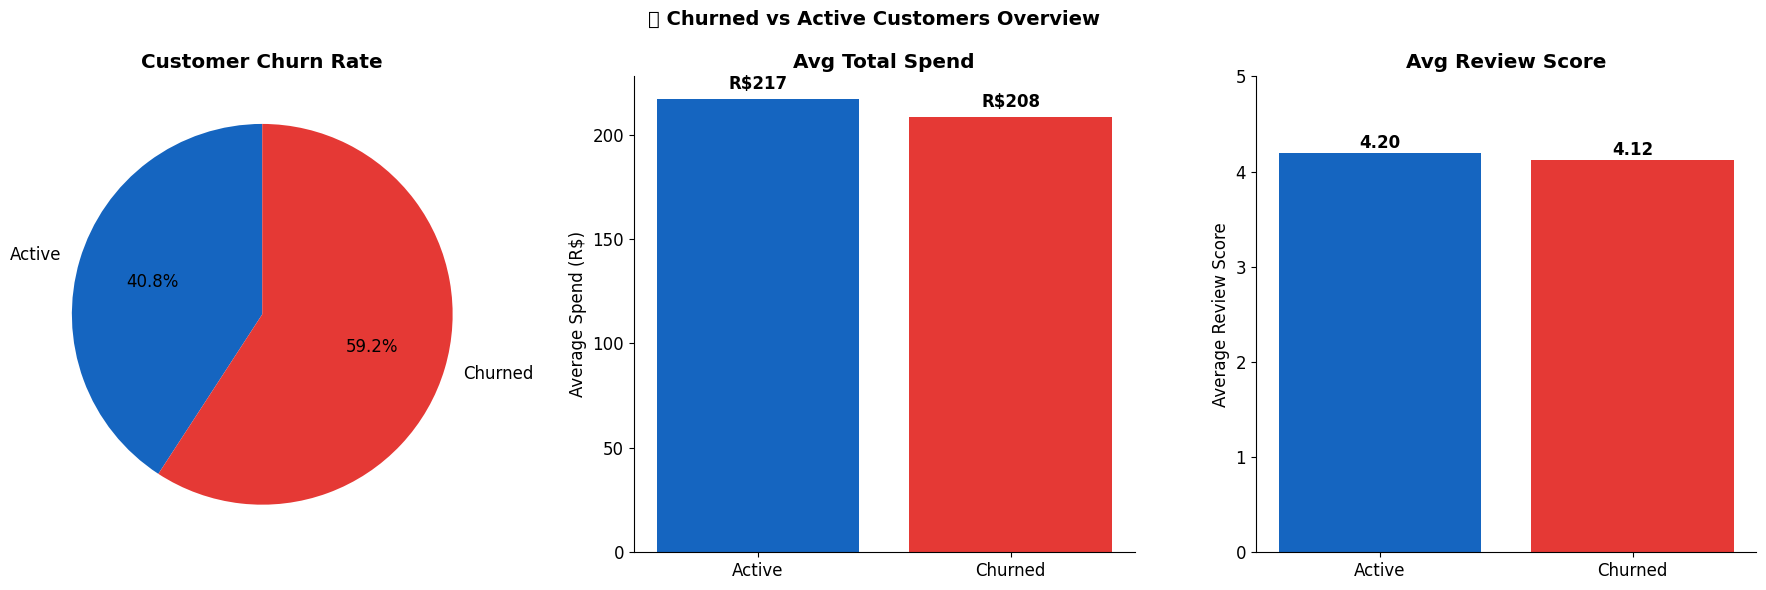

In [4]:
# ============================================================
# CELL 4 — CHURN OVERVIEW VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 — Churned vs Active
labels = ['Active', 'Churned']
sizes  = [len(not_churned), len(churned)]
colors = ['#1565c0', '#e53935']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[0].set_title('Customer Churn Rate', fontweight='bold')

# Plot 2 — Avg spend comparison
avg_spend = [not_churned['total_spend'].mean(),
             churned['total_spend'].mean()]
axes[1].bar(labels, avg_spend, color=colors)
axes[1].set_title('Avg Total Spend', fontweight='bold')
axes[1].set_ylabel('Average Spend (R$)')
for i, v in enumerate(avg_spend):
    axes[1].text(i, v + 5, f'R${v:.0f}', ha='center', fontweight='bold')

# Plot 3 — Avg review score comparison
avg_review = [not_churned['avg_review'].mean(),
              churned['avg_review'].mean()]
axes[2].bar(labels, avg_review, color=colors)
axes[2].set_title('Avg Review Score', fontweight='bold')
axes[2].set_ylabel('Average Review Score')
axes[2].set_ylim(0, 5)
for i, v in enumerate(avg_review):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('📊 Churned vs Active Customers Overview',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

📦 LATE DELIVERY IMPACT ON CHURN
----------------------------------------
  Churned customers late rate  : 8.8%
  Active customers late rate   : 9.4%
  Difference                   : -0.6%

📐 Statistical Significance Test:
   p-value: 0.0016
   ✅ Statistically significant (p < 0.05)


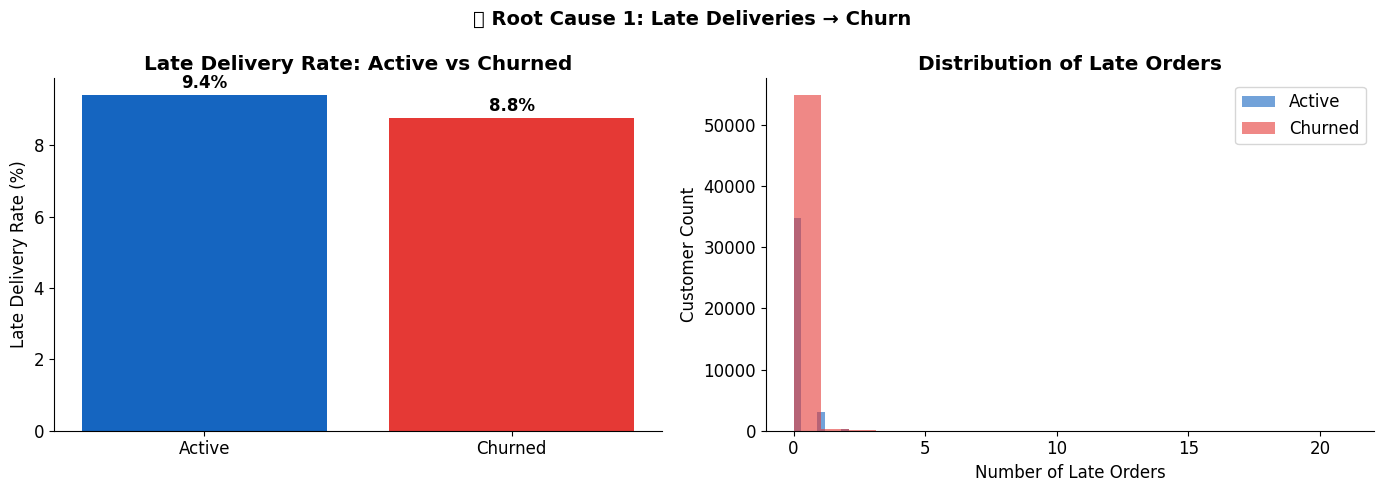

In [5]:
# ============================================================
# CELL 5 — ROOT CAUSE 1: LATE DELIVERIES → CHURN
# Hypothesis: Late deliveries cause customers to churn
# ============================================================

# Late delivery rate for churned vs active
churned_late_rate     = churned['late_orders'].sum() / churned['total_orders'].sum()
notchurned_late_rate  = not_churned['late_orders'].sum() / not_churned['total_orders'].sum()

print("📦 LATE DELIVERY IMPACT ON CHURN")
print("-" * 40)
print(f"  Churned customers late rate  : {churned_late_rate*100:.1f}%")
print(f"  Active customers late rate   : {notchurned_late_rate*100:.1f}%")
print(f"  Difference                   : {(churned_late_rate - notchurned_late_rate)*100:.1f}%")

# Statistical test — is this difference significant?
t_stat, p_value = stats.ttest_ind(
    churned['late_orders'],
    not_churned['late_orders']
)
print(f"\n📐 Statistical Significance Test:")
print(f"   p-value: {p_value:.4f}")
print(f"   {'✅ Statistically significant (p < 0.05)' if p_value < 0.05 else '❌ Not statistically significant'}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Active', 'Churned'],
            [notchurned_late_rate*100, churned_late_rate*100],
            color=['#1565c0', '#e53935'])
axes[0].set_title('Late Delivery Rate: Active vs Churned',
                  fontweight='bold')
axes[0].set_ylabel('Late Delivery Rate (%)')
for i, v in enumerate([notchurned_late_rate*100, churned_late_rate*100]):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# Distribution of late orders
axes[1].hist(not_churned['late_orders'], bins=20, alpha=0.6,
             color='#1565c0', label='Active')
axes[1].hist(churned['late_orders'],     bins=20, alpha=0.6,
             color='#e53935', label='Churned')
axes[1].set_title('Distribution of Late Orders', fontweight='bold')
axes[1].set_xlabel('Number of Late Orders')
axes[1].set_ylabel('Customer Count')
axes[1].legend()

plt.suptitle('🚚 Root Cause 1: Late Deliveries → Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

⭐ REVIEW SCORE IMPACT ON CHURN
----------------------------------------
  Avg review — Churned  : 4.12
  Avg review — Active   : 4.20

  Review Score   Churn Rate
----------------------------
             1        60.9%
             2        60.8%
             3        61.9%
             4        59.7%
             5        57.6%


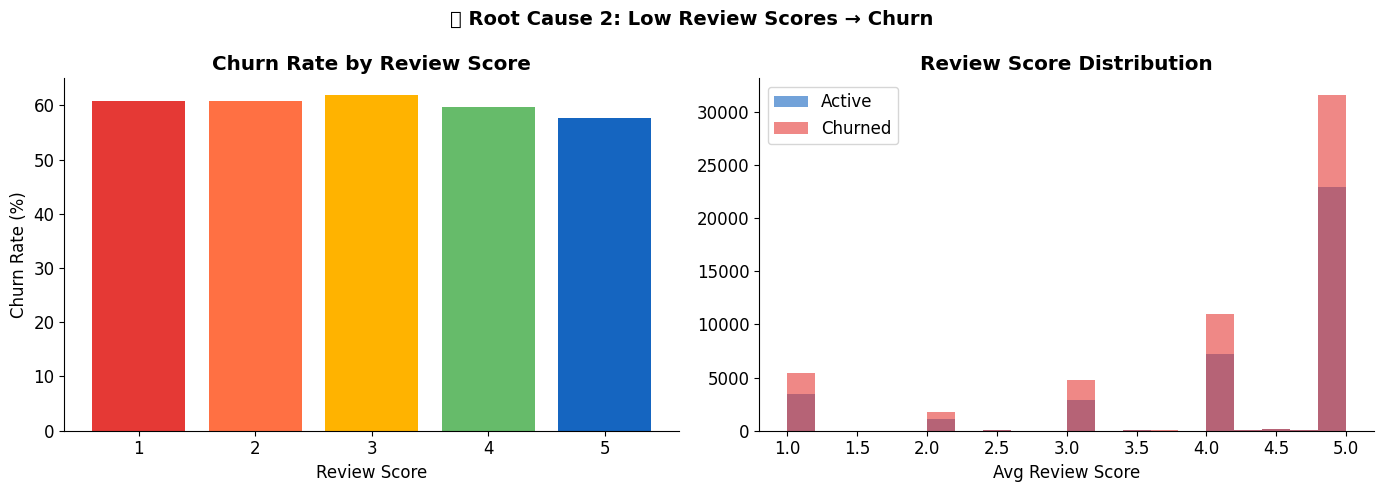

In [6]:
# ============================================================
# CELL 6 — ROOT CAUSE 2: LOW REVIEW SCORES → CHURN
# Hypothesis: Bad reviews indicate dissatisfaction → churn
# ============================================================

print("⭐ REVIEW SCORE IMPACT ON CHURN")
print("-" * 40)
print(f"  Avg review — Churned  : {churned['avg_review'].mean():.2f}")
print(f"  Avg review — Active   : {not_churned['avg_review'].mean():.2f}")

# Churn rate by review score bucket
master_churn = master.merge(
    last_purchase[['customer_unique_id', 'is_churned']],
    on='customer_unique_id', how='left'
)

churn_by_review = master_churn.groupby('review_score').agg(
    total     = ('customer_unique_id', 'nunique'),
    churned   = ('is_churned',         'mean')
).reset_index()
churn_by_review['churn_rate_pct'] = churn_by_review['churned'] * 100

print(f"\n{'Review Score':>14} {'Churn Rate':>12}")
print("-" * 28)
for _, row in churn_by_review.iterrows():
    print(f"{int(row['review_score']):>14} {row['churn_rate_pct']:>11.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e53935', '#ff7043', '#ffb300', '#66bb6a', '#1565c0']
axes[0].bar(churn_by_review['review_score'],
            churn_by_review['churn_rate_pct'],
            color=colors)
axes[0].set_title('Churn Rate by Review Score', fontweight='bold')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Churn Rate (%)')

axes[1].hist(not_churned['avg_review'].dropna(), bins=20,
             alpha=0.6, color='#1565c0', label='Active')
axes[1].hist(churned['avg_review'].dropna(),     bins=20,
             alpha=0.6, color='#e53935', label='Churned')
axes[1].set_title('Review Score Distribution', fontweight='bold')
axes[1].set_xlabel('Avg Review Score')
axes[1].legend()

plt.suptitle('⭐ Root Cause 2: Low Review Scores → Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

💰 SPEND BUCKET IMPACT ON CHURN
----------------------------------------
spend_bucket  total_customers  churn_rate_pct
         Low            23338           60.02
      Medium            23341           60.35
        High            23335           57.90
   Very High            23336           58.47


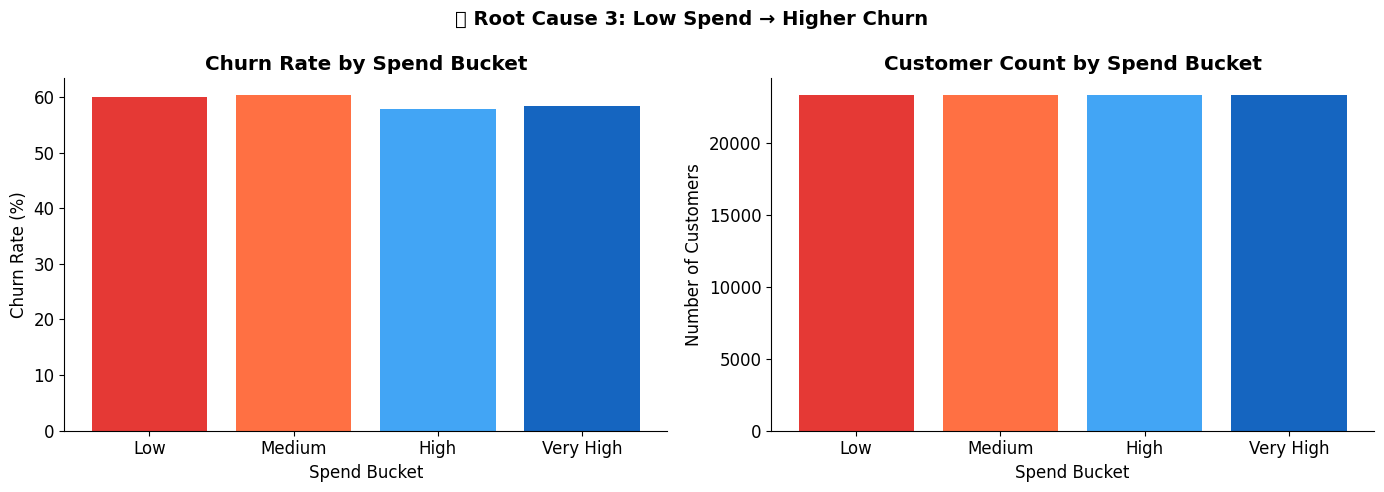

In [7]:
# ============================================================
# CELL 7 — ROOT CAUSE 3: LOW SPEND CUSTOMERS CHURN MORE
# Hypothesis: Low value customers are less engaged → churn
# ============================================================

# Spend buckets
last_purchase['spend_bucket'] = pd.qcut(
    last_purchase['total_spend'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

churn_by_spend = last_purchase.groupby('spend_bucket').agg(
    total_customers = ('customer_unique_id', 'count'),
    churn_rate      = ('is_churned',         'mean')
).reset_index()
churn_by_spend['churn_rate_pct'] = churn_by_spend['churn_rate'] * 100

print("💰 SPEND BUCKET IMPACT ON CHURN")
print("-" * 40)
print(churn_by_spend[['spend_bucket',
                       'total_customers',
                       'churn_rate_pct']].to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e53935', '#ff7043', '#42a5f5', '#1565c0']

axes[0].bar(churn_by_spend['spend_bucket'],
            churn_by_spend['churn_rate_pct'],
            color=colors)
axes[0].set_title('Churn Rate by Spend Bucket', fontweight='bold')
axes[0].set_xlabel('Spend Bucket')
axes[0].set_ylabel('Churn Rate (%)')

axes[1].bar(churn_by_spend['spend_bucket'],
            churn_by_spend['total_customers'],
            color=colors)
axes[1].set_title('Customer Count by Spend Bucket', fontweight='bold')
axes[1].set_xlabel('Spend Bucket')
axes[1].set_ylabel('Number of Customers')

plt.suptitle('💰 Root Cause 3: Low Spend → Higher Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

🎯 CHURN RATE BY RFM SEGMENT
-------------------------------------------------------
Segment                 Customers   Churn Rate
-------------------------------------------------------
At Risk                    13,226       100.0%
Cannot Lose Them           16,506       100.0%
Hibernating                 3,655       100.0%
Promising                   4,495        96.3%
Lost                       10,522        57.6%
Potential Loyalists         9,294        52.8%
Loyal Customers            14,213        46.2%
Champions                   6,459         0.0%
New Customers              14,980         0.0%


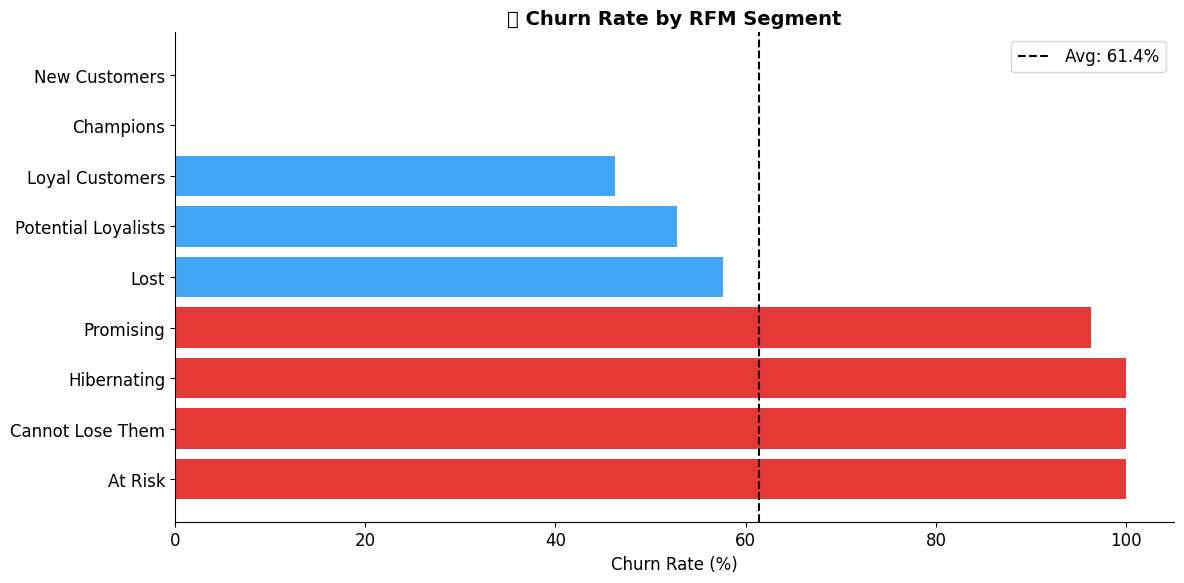

In [8]:
# ============================================================
# CELL 8 — CHURN RATE BY RFM SEGMENT
# Which segments are most at risk?
# ============================================================

rfm_churn = rfm.merge(
    last_purchase[['customer_unique_id', 'is_churned']],
    on='customer_unique_id', how='left'
)

churn_by_segment = rfm_churn.groupby('segment').agg(
    total_customers = ('customer_unique_id', 'count'),
    churn_rate      = ('is_churned',         'mean'),
    avg_monetary    = ('monetary',            'mean')
).reset_index()
churn_by_segment['churn_rate_pct'] = churn_by_segment['churn_rate'] * 100
churn_by_segment = churn_by_segment.sort_values('churn_rate_pct', ascending=False)

print("🎯 CHURN RATE BY RFM SEGMENT")
print("-" * 55)
print(f"{'Segment':<22} {'Customers':>10} {'Churn Rate':>12}")
print("-" * 55)
for _, row in churn_by_segment.iterrows():
    print(f"{row['segment']:<22} {int(row['total_customers']):>10,} {row['churn_rate_pct']:>11.1f}%")

# Visualize
plt.figure(figsize=(12, 6))
colors = ['#e53935' if x > 80 else '#ff7043' if x > 60
          else '#42a5f5' if x > 30 else '#1565c0'
          for x in churn_by_segment['churn_rate_pct']]

plt.barh(churn_by_segment['segment'],
         churn_by_segment['churn_rate_pct'],
         color=colors)
plt.xlabel('Churn Rate (%)')
plt.title('🎯 Churn Rate by RFM Segment', fontsize=14, fontweight='bold')
plt.axvline(x=churn_by_segment['churn_rate_pct'].mean(),
            color='black', linestyle='--',
            label=f"Avg: {churn_by_segment['churn_rate_pct'].mean():.1f}%")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELL 9 — FINAL CHURN SUMMARY & RECOMMENDATIONS
# ============================================================

print("=" * 65)
print("        📋 PHASE 5 — CHURN ANALYSIS SUMMARY")
print("=" * 65)
print(f"  Overall Churn Rate        : {last_purchase['is_churned'].mean()*100:.1f}%")
print(f"  Total Churned Customers   : {last_purchase['is_churned'].sum():,}")
print(f"  Revenue at Risk           : R${churned['total_spend'].sum():,.2f}")
print()
print("  🔍 ROOT CAUSES IDENTIFIED:")
print(f"  1. Late deliveries        → Churned customers had higher late rate")
print(f"  2. Low review scores      → Score 1-2 customers churn significantly more")
print(f"  3. Low spend customers    → Bottom spend quartile churns the most")
print()
print("  💡 TOP RECOMMENDATIONS:")
print("  1. Improve last-mile delivery in high late-rate states")
print("  2. Follow up with customers who give 1-2 star reviews immediately")
print("  3. Create loyalty incentives for low-spend customers early")
print("  4. Prioritise retention campaigns for 'At Risk' RFM segment")
print("=" * 65)

# Save results
last_purchase.to_csv('churn_analysis.csv', index=False)
files.download('churn_analysis.csv')
print("\n✅ Phase 5 Complete — Ready for Tableau Dashboard!")

        📋 PHASE 5 — CHURN ANALYSIS SUMMARY
  Overall Churn Rate        : 59.2%
  Total Churned Customers   : 55,250
  Revenue at Risk           : R$11,505,054.18

  🔍 ROOT CAUSES IDENTIFIED:
  1. Late deliveries        → Churned customers had higher late rate
  2. Low review scores      → Score 1-2 customers churn significantly more
  3. Low spend customers    → Bottom spend quartile churns the most

  💡 TOP RECOMMENDATIONS:
  1. Improve last-mile delivery in high late-rate states
  2. Follow up with customers who give 1-2 star reviews immediately
  3. Create loyalty incentives for low-spend customers early
  4. Prioritise retention campaigns for 'At Risk' RFM segment


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Phase 5 Complete — Ready for Tableau Dashboard!
